## Example use case of the tsib.CREST module

Author: Leander Kotzur

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

### 1. Show the generator for a single profile

Import tsib.CREST

In [2]:
import tsorb.ElectricalLoadProfile as elp
import pandas as pd
import holidays
import numpy as np

r"tsib/tsib/data/weatherdata/TRY/TRY2010_09_Jahr.dat"Initialize the object

In [3]:
path = r"C:\Users\Samuel\FH_Aachen\tsib_simuflex_fork\tsib_simuflex\tsib\data\weatherdata\TRY2015\02\TRY2015_533953141468_Jahr.dat"

In [4]:
weather = pd.read_csv(path, sep=r"\s+", skiprows=32).drop([0])
weather["GHI"] = weather["B"] + weather["D"]

In [5]:
weather.index = pd.to_datetime({
    "year": 2025,
    "month": weather["MM"],
    "day": weather["DD"],
    "hour": weather["HH"] -1 ,
                })

In [6]:
weather

,RW,HW,MM,DD,HH,t,p,WR,WG,N,x,RF,B,D,A,E,IL,GHI
2025-01-01 00:00:00,4266500,2957500.0,1.0,1.0,1.0,-3.0,1020.0,256.0,5.3,6.0,2.9,93.0,0.0,0.0,219.0,-270.0,1.0,0.0
2025-01-01 01:00:00,4266500,2957500.0,1.0,1.0,2.0,-4.1,1020.0,251.0,5.6,6.0,2.6,93.0,0.0,0.0,219.0,-269.0,1.0,0.0
2025-01-01 02:00:00,4266500,2957500.0,1.0,1.0,3.0,-4.7,1020.0,250.0,5.9,7.0,2.4,93.0,0.0,0.0,228.0,-268.0,1.0,0.0
2025-01-01 03:00:00,4266500,2957500.0,1.0,1.0,4.0,-4.0,1020.0,259.0,5.9,7.0,2.5,93.0,0.0,0.0,237.0,-267.0,1.0,0.0
2025-01-01 04:00:00,4266500,2957500.0,1.0,1.0,5.0,-3.4,1020.0,266.0,5.9,8.0,2.7,93.0,0.0,0.0,238.0,-265.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 19:00:00,4266500,2957500.0,12.0,31.0,20.0,1.0,1018.0,272.0,4.9,4.0,3.7,92.0,0.0,0.0,252.0,-315.0,1.0,0.0
2025-12-31 20:00:00,4266500,2957500.0,12.0,31.0,21.0,1.1,1018.0,274.0,4.7,6.0,3.7,92.0,0.0,0.0,268.0,-317.0,1.0,0.0
2025-12-31 21:00:00,4266500,2957500.0,12.0,31.0,22.0,1.1,1018.0,276.0,4.4,6.0,3.8,93.0,0.0,0.0,287.0,-319.0,1.0,0.0
2025-12-31 22:00:00,4266500,2957500.0,12.0,31.0,23.0,0.0,1018.0,271.0,4.6,6.0,3.5,93.0,0.0,0.0,287.0,-319.0,1.0,0.0


In [7]:
de_holidays = holidays.country_holidays(country="DE",years=2025)

In [8]:
np.random.seed(142)
single = elp.ElectricalLoadProfile(get_hot_water = True, resample_mean=False, freq="1min", holidays=de_holidays, resolved_load=True, weather_data=weather, residents=5)


In [48]:
#load = single.run_for_year(2025)

In [9]:
res = single.get_rescheduled_profiles(2025)
water = [a.get_key for a in single.app_model.loads if a.type_name == "Water heating"]
res_plot = res.drop(columns=water, errors="ignore")

C:\Users\Samuel\FH_Aachen\tsorb_fork\tsorb_simuflex\tsorb\utils\DPD.py:24: RuntimeWarning: invalid value encountered in scalar divide
  self._values[i] /= sum
C:\Users\Samuel\FH_Aachen\tsorb_fork\tsorb_simuflex\tsorb\utils\DPD.py:24: RuntimeWarning: invalid value encountered in scalar divide
  self._values[i] /= sum
C:\Users\Samuel\FH_Aachen\tsorb_fork\tsorb_simuflex\tsorb\utils\DPD.py:24: RuntimeWarning: invalid value encountered in scalar divide
  self._values[i] /= sum
C:\Users\Samuel\FH_Aachen\tsorb_fork\tsorb_simuflex\tsorb\utils\DPD.py:24: RuntimeWarning: invalid value encountered in scalar divide
  self._values[i] /= sum
C:\Users\Samuel\FH_Aachen\tsorb_fork\tsorb_simuflex\tsorb\utils\DPD.py:24: RuntimeWarning: invalid value encountered in scalar divide
  self._values[i] /= sum
C:\Users\Samuel\FH_Aachen\tsorb_fork\tsorb_simuflex\tsorb\utils\DPD.py:24: RuntimeWarning: invalid value encountered in scalar divide
  self._values[i] /= sum
C:\Users\Samuel\FH_Aachen\tsorb_fork\tsorb_sim

In [50]:
occ = pd.DataFrame(
    {"OccActive": single.occ_active, "OccNotActive": single.occ_not_active},
    index=pd.date_range("2025-01-01", periods=len(single.occ_active), freq="10min"),
).astype(int)

# occ_1min = occ.reindex(load.index, method="ffill")    # same minute grid as the load
# both = load.join(occ_1min)                            # optional: single DataFrame

In [51]:
types = {a.get_key: a.type_name for a in single.app_model.loads
         if a.type_name != "Water heating"}

In [52]:
doy = pd.Timestamp("2025-07-28").dayofyear
a  = single.occ_active.reshape(-1, 144)[doy - 1]
na = single.occ_not_active.reshape(-1, 144)[doy - 1]
print("min active:", a.min(), "| night active (00-06h):", a[:36])
print("home total range:", (a + na).min(), (a + na).max())

min active: 0.0 | night active (00-06h): [1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.]
home total range: 1.0 5.0


In [53]:
(single.occ_active.reshape(-1, 144).min(1) > 0).sum()

np.int64(1)

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


def plot_resolved_day(load_resolved, day, types=None, min_peak=0.0, path=None, ghi=None, occ=None):
    """One subplot per appliance for a single day.

    load_resolved: DataFrame from run_for_year(..., resolved_load=True)
    day:           e.g. "2023-03-14"
    types:         optional {appliance key: type name} to colour/sort by type
    min_peak:      hide appliances whose peak power (W) is <= this value
    """
    df = load_resolved.loc[day]
    total = df.sum(axis=1)
    df = df.loc[:, df.max() > min_peak]          # drop not-owned / never-used
    if types:
        df = df[sorted(df.columns, key=lambda c: (types.get(c, "Lighting"), c))]
    rows = list(df.columns)                       # replaces n = len(df.columns)
    if ghi is not None:
        ghi_day = ghi.copy()
        if ghi_day.index.tz is not None:          # the load index is tz-naive
            ghi_day.index = ghi_day.index.tz_localize(None)
        ghi_day = ghi_day.loc[day]
        rows.insert(rows.index("LIGHTS") + 1 if "LIGHTS" in rows else len(rows), "GHI")

    n = len(rows)
    if occ is not None:
        occ_day = occ.loc[day]
    n_top = 1 + (occ is not None)
    cmap = plt.get_cmap("tab10")
    kinds = sorted({types.get(c, "Lighting") for c in df.columns}) if types else []
    colour = {k: cmap(i % 10) for i, k in enumerate(kinds)}

    fig, axes = plt.subplots(
        n + n_top, 1, figsize=(11, 0.75 * n + 3.5 + 1.2 * (n_top - 1)), sharex=True, squeeze=False,
        gridspec_kw={"height_ratios": [4] + [1.6] * (n_top - 1) + [1] * n},
    )

    top = axes[0, 0]
    top.fill_between(total.index, total, step="post", color="black", alpha=0.75, linewidth=0)
    top.set_ylim(0, total.max() * 1.1)
    top.set_ylabel("TOTAL\n(W)", rotation=0, ha="right", va="center", fontsize=9, fontweight="bold")
    top.tick_params(axis="y", labelsize=7)
    top.grid(axis="y", alpha=0.3)
    kwh = total.sum() / 60 / 1000
    top.text(0.995, 0.92, f"peak {total.max():.0f} W | {kwh:.1f} kWh", transform=top.transAxes,
             ha="right", va="top", fontsize=8)
    for s in ("top", "right"):
        top.spines[s].set_visible(False)
    if occ is not None:
        oax = axes[1, 0]
        act = occ_day["OccActive"]
        inact = occ_day["OccNotActive"]
        oax.fill_between(act.index, act, step="post", color="#2a9d8f", linewidth=0, label="home, active")
        oax.fill_between(act.index, act, act + inact, step="post", color="#a8dadc", linewidth=0, label="home, not active")
        oax.set_ylim(0, max((act + inact).max(), 1) * 1.2)
        oax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=4))
        oax.set_ylabel("OCCUPANTS", rotation=0, ha="right", va="center", fontsize=9, fontweight="bold")
        oax.tick_params(axis="y", labelsize=7)
        oax.legend(loc="lower right", bbox_to_anchor=(1, 1), ncol=2, fontsize=7, frameon=False)
        for s in ("top", "right"):
            oax.spines[s].set_visible(False)

    for ax, col in zip(axes[n_top:, 0], rows):
        if col == "GHI":
            ax.fill_between(ghi_day.index, ghi_day, step="post", color="goldenrod", alpha=0.5, linewidth=0)
            ax.plot(ghi_day.index, ghi_day, drawstyle="steps-post", color="goldenrod", linewidth=1)
            ax.set_ylim(0, max(ghi_day.max(), 1) * 1.15)
            ax.set_yticks([0, round(ghi_day.max())])
            ax.set_ylabel("GHI (W/m²)", rotation=0, ha="right", va="center", fontsize=8, style="italic")
            ax.tick_params(axis="y", labelsize=7)
            for sp in ("top", "right"):
                ax.spines[sp].set_visible(False)
            continue
        c = colour.get(types.get(col, "Lighting"), "C0") if types else "C0"
        ax.fill_between(df.index, df[col], step="post", color=c, alpha=0.8, linewidth=0)
        ax.set_ylim(0, df[col].max() * 1.15)
        ax.set_yticks([0, round(df[col].max())])
        ax.set_ylabel(col, rotation=0, ha="right", va="center", fontsize=8)
        ax.tick_params(axis="y", labelsize=7)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
    axes[-1, 0].xaxis.set_major_locator(mdates.HourLocator(interval=2))
    axes[-1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    axes[-1, 0].set_xlim(df.index[0], df.index[-1])
    fig.suptitle(f"Load per appliance, {day} (W)", x=0.01, ha="left")
    if types:
        handles = [plt.Rectangle((0, 0), 1, 1, color=colour[k]) for k in kinds]
        fig.legend(handles, kinds, loc="upper right", ncol=len(kinds), fontsize=7, frameon=False)
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    if path:
        fig.savefig(path, dpi=130)
    #return fig

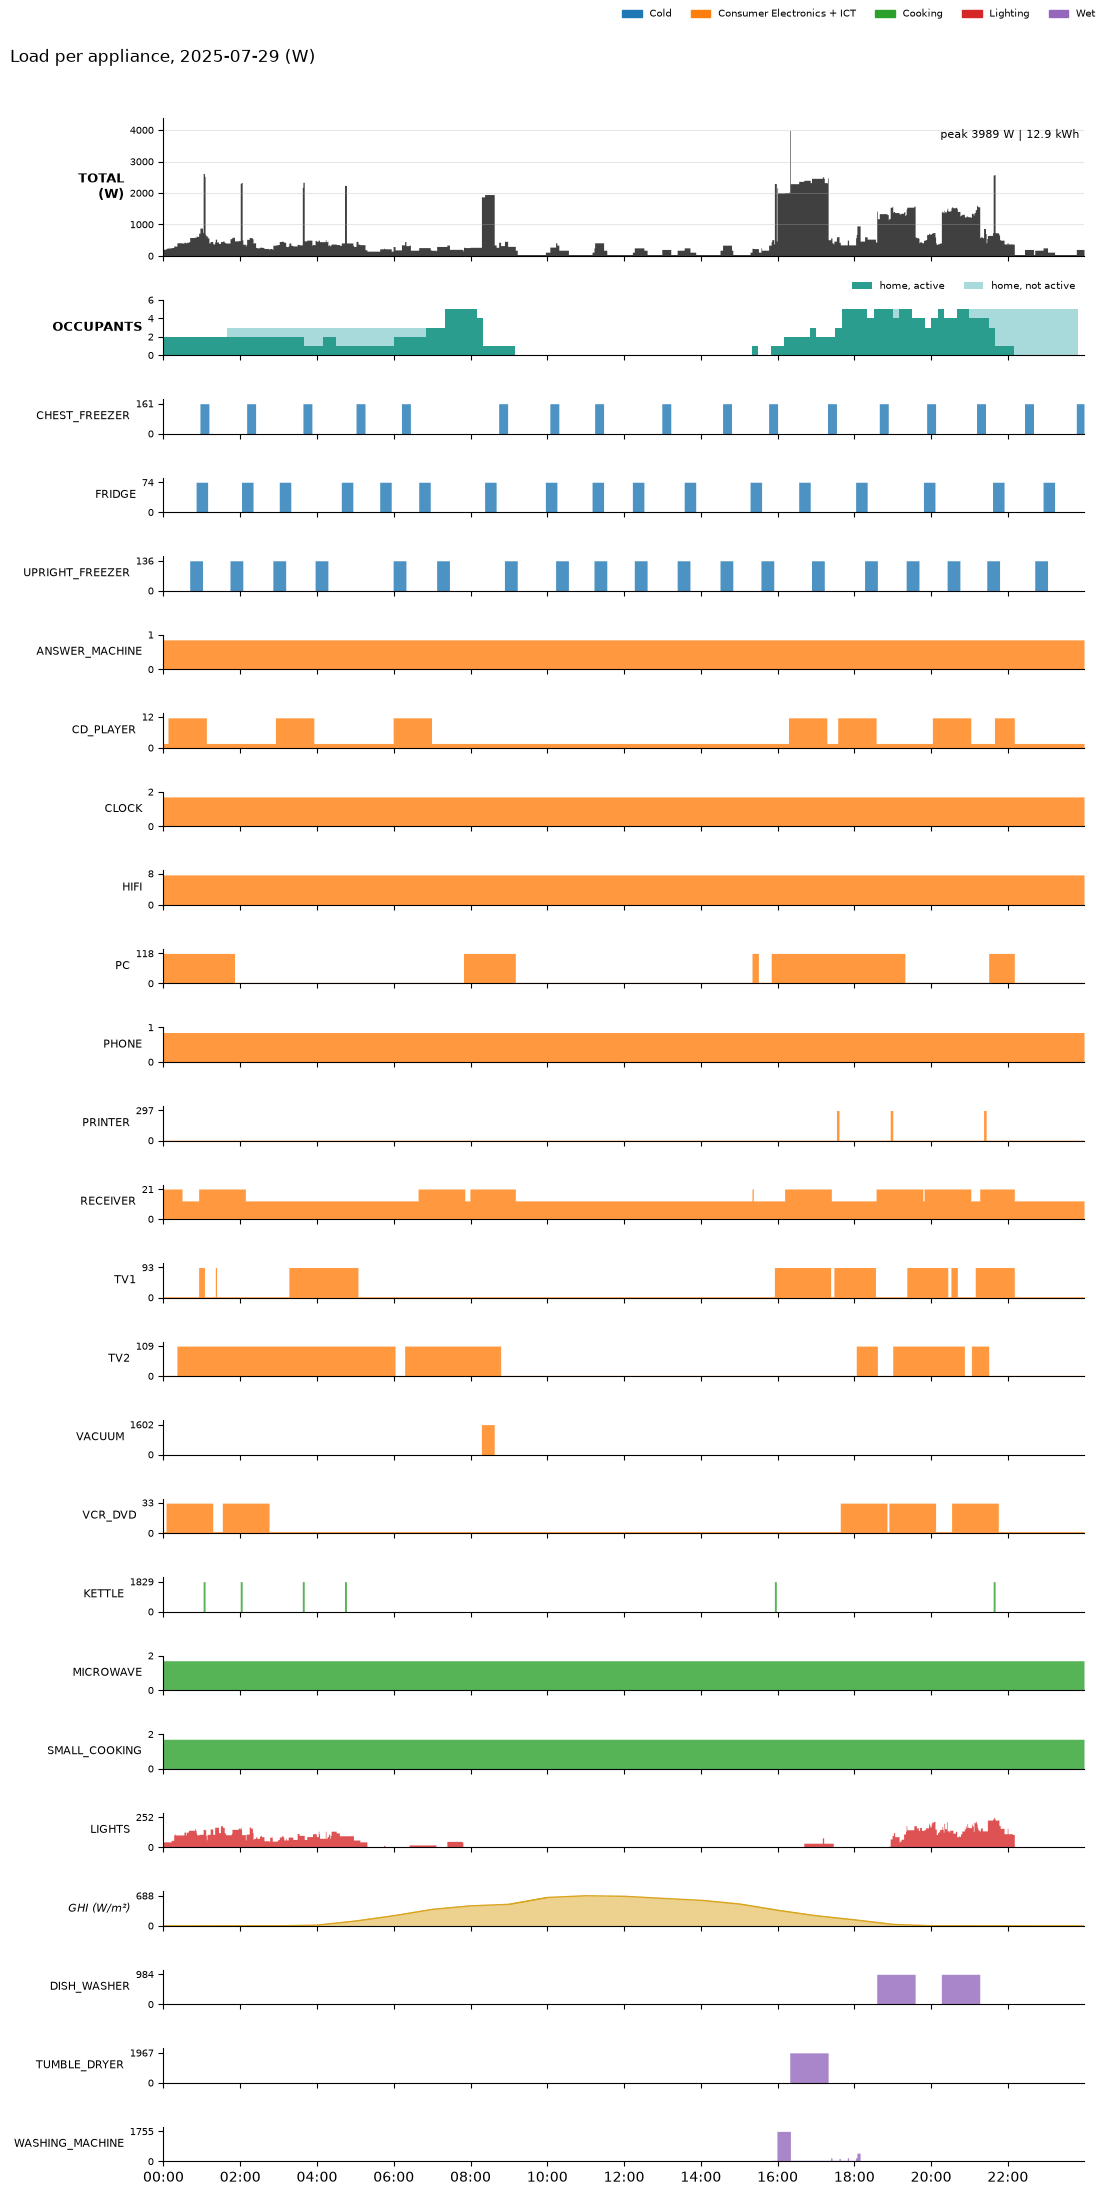

In [39]:
ghi= weather["GHI"].resample("1min").mean().interpolate()
plot_resolved_day(res_plot, "2025-07-29", types, ghi=ghi, occ=occ)